# Analisis de placa radiocromica

Analisis de imagen para la placa radiocromica irradiada en el servicio de radioterapia de AUNA por un acelerador lineal cualesquiera.

El objetivo es detectar 5 puntos en la imagen, unir los puntos, trazar un cuadrado y hacer las siguientes mediciones:

- El FWHM cross-plane e in-plane.
- El desfase del cuadrado trazado respecto a los bordes del perfil al nivel de FWHM. (Para esto se podria usar el trazado de puntos, dibujar la linea, identificar el pixel en la region central, trazar los perfiles cross-plane e in-plane y segun este pixel fijar un posicion en este perfil y definir la posicion respecto a este punto en la curva con el pixel de referencia, definir la distancia entre los pixeles y hacer la conversion a longitud.)

In [1]:
import sys

print(sys.executable)
print(sys.version)

/home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/bin/python
3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]


## Librerias

In [2]:
import numpy as np
import scipy as sp
from scipy.fft import fft2
from scipy.fft import ifft2
from scipy.fft import fftfreq
from scipy.fft import fftshift, ifftshift
from scipy.signal import convolve2d

import imageio

import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from matplotlib.animation import PillowWriter
import pint

from PIL import Image

u = pint.UnitRegistry()

### Funciones auxiliares

In [3]:
def normalize_image(image):
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return normalized_image

def intensidad_del_campo(campo):
    intensidad_espectro_imagen = np.abs(campo)**2
    return intensidad_espectro_imagen

## Operaciones iniciales con la imagen

En caso de que sea mejor usar una imagen .TIF y con el flag de unchanged de cv2.imread() hay que decirle a claude que lo tenga en cuenta y que ajuste eso al de braqui tambien.

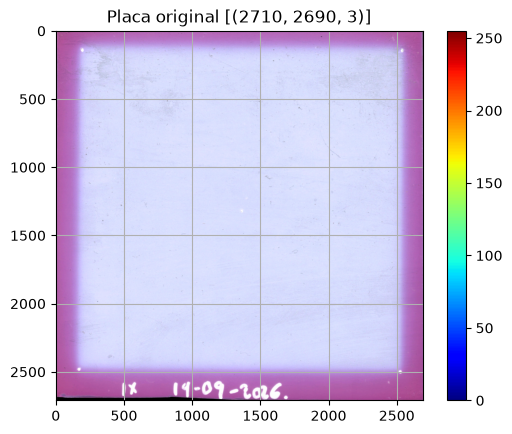

In [4]:
ruta_imagen = '/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/PlacasHistoricas/ML0.JPG'

placa_analizada = cv2.bitwise_not(cv2.imread(ruta_imagen, 1))
placa_analizada_gray = cv2.bitwise_not(cv2.imread(ruta_imagen, 0))

plt.imshow(placa_analizada, cmap = 'jet')
plt.title(f"Placa original [{np.shape(placa_analizada)}]")
plt.colorbar()
plt.grid()
plt.show()

In [5]:
tamano_pixel = 25.4/600 # Escaneado a 600 dpi, tamaño de pixel en mm

## Ubicacion manual de los puntos de referencia

A partir de las esquinas del campo luminoso que se proyecta sobre la placa y el centro del crosshair del acelerador se hacen unas marcas sobre la pelicula radiocromica, en esta parte lo unico que haremos es identificar manualmente la posicion para descargarle responsabilidad al proceso automatico y bajar la dificultad de construir un umbral que automaticamente identifique las coordenadas de estos puntos.

QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/felipepp/Documents/CodigosPython/Codigo_AnalisisImagen/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no long

Puntos guardados (coordenadas [x, y]): [(196, 143), (2542, 147), (1363, 1318), (171, 2484), (2526, 2505)]


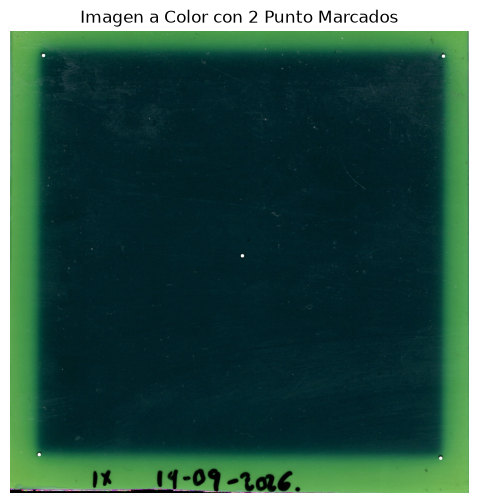

In [6]:
# --- 1. Aplicar mapa de color a la imagen base ---
# Convertimos el float32 [0.0, 1.0] a uint8 [0, 255] para aplicar el mapa de color de OpenCV
img_uint8 = (placa_analizada* 255).clip(0, 255).astype(np.uint8)

# Aplicar mapa de color (Puedes cambiar cv2.COLORMAP_JET por:
# COLORMAP_VIRIDIS, COLORMAP_HOT, COLORMAP_TURBO, COLORMAP_PLASMA, COLORMAP_BONE)
# placa_color_bgr = cv2.applyColorMap(img_uint8, cv2.COLORMAP_JET)

# Convertir de vuelta a float32 [0.0, 1.0] para trabajar uniformemente
placa_color = img_uint8.astype(np.float32) / 255.0

puntos = []

def seleccionar_puntos(event, x, y, flags, param):
    global puntos, placa_color

    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 5:
        puntos.append((x, y))

        # Dibujar punto con intensidad de contraste sobre el mapa de calor
        # (1.0, 1.0, 1.0) = Blanco puro | (0.0, 0.0, 0.0) = Negro puro
        cv2.circle(placa_color, (x, y), 10, (1.0, 1.0, 1.0), -1)


# --- 2. Interfaz interactiva OpenCV ---
cv2.namedWindow("Seleccionar 5 Puntos", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Seleccionar 5 Puntos", seleccionar_puntos)
cv2.resizeWindow("Seleccionar 5 Puntos", 1280, 720)

while True:
    cv2.imshow("Seleccionar 5 Puntos", placa_color)

    key = cv2.waitKey(1) & 0xFF
    if key == 27 or len(puntos) == 5:
        if len(puntos) == 5:
            cv2.imshow("Seleccionar 5 Punto", placa_color)
            cv2.waitKey(300)
        break

cv2.destroyAllWindows()
cv2.waitKey(1)

# --- 3. Renderizado inline dentro del Notebook ---
print(f"Puntos guardados (coordenadas [x, y]): {puntos}")

# Convertir BGR a RGB para mostrar exactamente lo mismo en Matplotlib
placa_color_rgb = cv2.cvtColor(
    (placa_color * 255).astype(np.uint8), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(placa_color_rgb)
plt.title("Imagen a Color con 2 Punto Marcados")
plt.axis("off")
plt.show()

plt.imsave('/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/Placas_codigo/placa_0.jpeg', placa_color_rgb)

Identificamos los puntos asumiendo una localizacion por cuadrantes.

In [7]:
for i in puntos: # Podemos dejar el ancho de la region central tambien como una variable expuesta la usuario
    if  (int(np.shape(placa_analizada)[0]//2) - 100) < int(i[0]) < (int(np.shape(placa_analizada)[0]//2) + 100) and (int(np.shape(placa_analizada)[1]//2) - 100) < int(i[1]) < (int(np.shape(placa_analizada)[1]//2) + 100):
        punto_CC_0 = i
    else:
        if int(i[0]) < int(np.shape(placa_analizada)[0]//2):
            # Region horizontal a la izquiera
            if int(i[1]) > int(np.shape(placa_analizada)[1]//2):
                punto_DL_0 = i
            else:
                punto_UL_0 = i
        else:
            # Region horizontal a la derecha
            if int(i[1]) > int(np.shape(placa_analizada)[1]//2):
                punto_DR_0  = i
            else:
                punto_UR_0 = i

print(f"Coordenada arriba izquierda: {punto_UL_0}")
print(f"Coordenada arriba derecha: {punto_UR_0}")
print(f"Coordenada abajo izquierda: {punto_DL_0}")
print(f"Coordenada abajo derecha: {punto_DR_0}")
print(f"Coordenada punto central {punto_CC_0}")

Coordenada arriba izquierda: (196, 143)
Coordenada arriba derecha: (2542, 147)
Coordenada abajo izquierda: (171, 2484)
Coordenada abajo derecha: (2526, 2505)
Coordenada punto central (1363, 1318)


Haremos el trazado de lo que corresponde idealmente al campo luminoso, aqui no es necesario hacerlo sobre la imagen, pues solo necesitamos visualizar la forma del campo luminoso y hacer operaciones con los puntos identificados, que son solo coordenadas sobre una imagen:

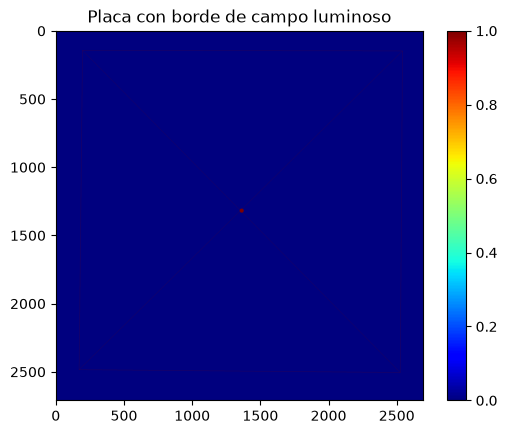

In [8]:
fondo = np.zeros(np.shape(placa_analizada_gray))

valor_trazos = 1
grosor_trazo = 1

cv2.line(fondo, punto_UL_0, punto_UR_0, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UL_0, punto_DL_0, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UL_0, punto_DR_0, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_DL_0, punto_UR_0, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_UR_0, punto_DR_0, valor_trazos, grosor_trazo)
cv2.line(fondo, punto_DL_0, punto_DR_0, valor_trazos, grosor_trazo)

# cv2.circle(fondo, (int(np.round(x_0, 0)), int(np.round(y_0, 0))), 15, color = 1, thickness = -1)
cv2.circle(fondo, punto_CC_0, 15, color = 1, thickness = -1)

plt.imshow(fondo, cmap = 'jet')
plt.title("Placa con borde de campo luminoso")
plt.colorbar()
plt.show()

Ahora con esta informacion podemos ajustar la inclinacion de la imagen en caso de que esta este torcida respecto a la vertical de mi eje.

### Extraccion del angulo

Utilizaremos el angulo de las diagonales para alinear correctamente el rectangulo respecto a la vertical de mi imagen, que se traza desde las esquinas del campo luminoso.

In [9]:
tetha_0 =  45 - 1 * np.degrees(np.arctan((punto_UL_0[0] - punto_DR_0[0])/(punto_UL_0[1] - punto_DR_0[1])))
print(f"Diagonal tetha_0: {tetha_0}")

tetha_1 =  45 + 1 * np.degrees(np.arctan((punto_UR_0[0] - punto_DL_0[0])/(punto_UR_0[1] - punto_DL_0[1])))
print(f"Diagonal tetha_1: {tetha_1}")

if np.abs(tetha_1) > np.abs(tetha_0):

    mean_tetha = - 1 * tetha_1
else:
    mean_tetha = tetha_0

# mean_tetha = (tetha_0 + tetha_1)/2
print(f"Diagonal mean_tetha: {mean_tetha}")

Diagonal tetha_0: 0.3907579961492047
Diagonal tetha_1: -0.4137686147837414
Diagonal mean_tetha: 0.4137686147837414


Ahora segun el angulo medio medido debemos rotar la imagen con operaciones matriciales el angulo opuesto al que se calcula. Sin embargo, aparte del angulo necesitamos el centro de rotacion, y ya que estamos usando directamente las diagonales, tomaremos como centro de rotacion la interseccion entre estas calculado con el metodo de interseccion entre rectas.

In [10]:
# Puntos diagonal 1: Arriba izquierda y abajo derecha
# Pendiente diagonal 1:
m_1 = (punto_DR_0[1] - punto_UL_0[1])/(punto_DR_0[0] - punto_UL_0[0])

# Puntos diagonal 2: Arriba derecha y abajo izquierda
# Pendiente diagonale 2:
m_2 = (punto_UR_0[1] - punto_DL_0[1])/(punto_UR_0[0] - punto_DL_0[0])

# Puntos de interseccion de cada diagonal con el eje y
b_1 = punto_DR_0[1] - punto_DR_0[0] * m_1
b_2 = punto_UR_0[1] - punto_UR_0[0] * m_2

x_0 = (b_2 - b_1)/(m_1 - m_2) # Resolviendo igualando las rectas en y

y_0 = m_1 * x_0 + b_1 # Punto en y para el valor de x hallado

cc_diagonales = (int(np.round(x_0, 0)), int(np.round(y_0, 0)))

print(f"El punto de interseccion de las rectas esta en: {cc_diagonales}")

El punto de interseccion de las rectas esta en: (1355, 1317)


El centro de rotacion no cambia de posicion luego de la transformacion, en este caso nuestro centro de rotacion por orden de Adriana va a ser el de la interseccion de las diagonales. Sin embargo, todos los demas puntos cambian de posicion segun la rotacion de la matriz de la imagen, es imperativo entonces predecir la posicion resultante de estos puntos.

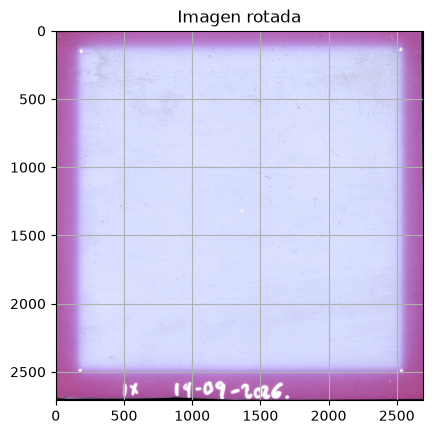

In [11]:
centro_rotacion = cc_diagonales

placa_matriz_transformacion = cv2.getRotationMatrix2D(
    centro_rotacion,
    mean_tetha, 1)

placa_rotada = cv2.warpAffine(placa_analizada, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_analizada)[1], np.shape(placa_analizada)[0]))

plt.imshow(placa_rotada)
plt.title('Imagen rotada')
plt.grid()
plt.show()

Ahora debemos encontrar las nuevas posiciones de los puntos rotados.

In [12]:
puntos

[(196, 143), (2542, 147), (1363, 1318), (171, 2484), (2526, 2505)]

In [13]:
arr_puntos = np.array(puntos)

puntos_rotados_tetha = cv2.transform(
    arr_puntos.reshape(-1, 1, 2),
    placa_matriz_transformacion
)

puntos_rotados_tetha = puntos_rotados_tetha.reshape(-1, 2).tolist()

print(f"Nueva posicion puntos de referencia: {puntos_rotados_tetha}")

Nueva posicion puntos de referencia: [[188, 151], [2534, 138], [1363, 1318], [179, 2493], [2535, 2497]]


Es importante tener en cuenta que no quedara perfectamente vertical, debido a que el tetha medio no es igual a el desfase en inclinacion respecto a los 45 grados de ninguna de las dos diagonales, por lo cual el ajuste NO alinea con respecto a 45 grados a ninguna de las diagonales.

Volvamos a sacar entonces las posiciones de cada uno de los puntos, con las nuevas coordenadas logicamente.

In [14]:
for i in puntos_rotados_tetha: # Podemos dejar el ancho de la region central tambien como una variable expuesta la usuario
    if  (int(np.shape(placa_analizada)[0]//2) - 100) < int(i[0]) < (int(np.shape(placa_analizada)[0]//2) + 100) and (int(np.shape(placa_analizada)[1]//2) - 100) < int(i[1]) < (int(np.shape(placa_analizada)[1]//2) + 100):
        punto_CC = i
    else:
        if int(i[0]) < int(np.shape(placa_analizada)[0]//2):
            # Region horizontal a la izquiera
            if int(i[1]) > int(np.shape(placa_analizada)[1]//2):
                punto_DL = i
            else:
                punto_UL = i
        else:
            # Region horizontal a la derecha
            if int(i[1]) > int(np.shape(placa_analizada)[1]//2):
                punto_DR = i
            else:
                punto_UR = i

print(f"Coordenada arriba izquierda: {punto_UL}")
print(f"Coordenada arriba derecha: {punto_UR}")
print(f"Coordenada abajo izquierda: {punto_DL}")
print(f"Coordenada abajo derecha: {punto_DR}")
print(f"Coordenada punto central {punto_CC}")

# Ahora debemos calcular la distancia por coordenada:
desfase_cx = (punto_CC[0] - x_0) * tamano_pixel
desfase_cy = (punto_CC[1] - y_0) * tamano_pixel

print(f"Desfase de centro en crossplane: {np.round(desfase_cx, 3)} mm")
print(f"Desfase de centro en inplane: {np.round(desfase_cy, 3)} mm")

Coordenada arriba izquierda: [188, 151]
Coordenada arriba derecha: [2534, 138]
Coordenada abajo izquierda: [179, 2493]
Coordenada abajo derecha: [2535, 2497]
Coordenada punto central [1363, 1318]
Desfase de centro en crossplane: 0.359 mm
Desfase de centro en inplane: 0.024 mm


Estos puntos solo se tienen que sacar una vez porque la posicion no cambia, ni deberia ni por capas de color ni escala de grises, obvio mucho menos cuando se hace el simple trazado de las lineas de campo luminoso sobre un fondo cero.

## Separacion por capas de color de la imagen

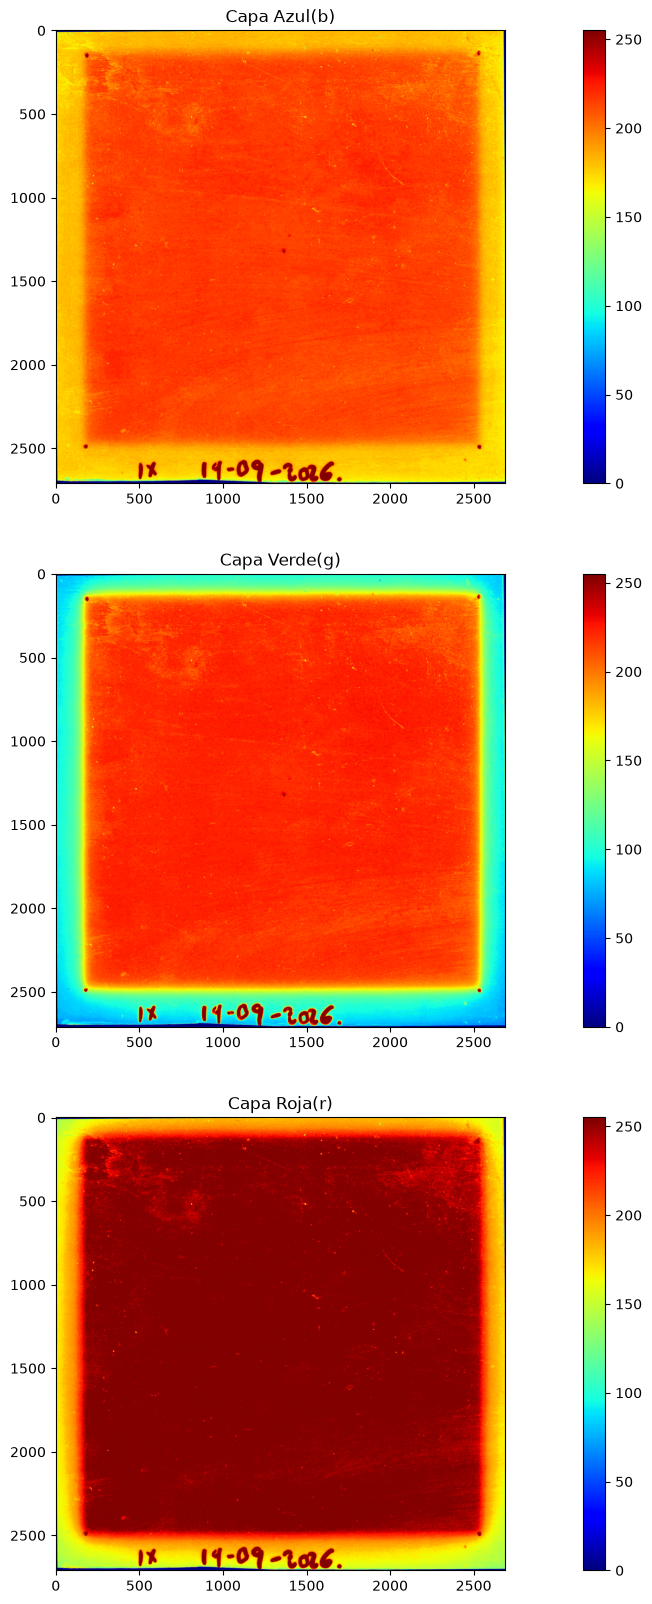

In [15]:
b, g, r = cv2.split(placa_rotada) # Sacado directamente de geeksforgeeks

plt.figure(figsize = (20, 20))

plt.subplot(3, 1, 1)
plt.imshow(b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3) # Numero filas, columnas, posicion especifica.
plt.imshow(r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

Para estas graficas hemos preferido utilizar la imagen cruda y dejar la de los puntos solo para tener las coordenadas de los puntos y definir el cuadrado del campo luminoso y alinear la imagen, esencialmente esa es su unica funcion. La imagen cruda nos permite tener solo los niveles de ruido naturales de la prueba, no inducidos aqui por el analisis que llevemos a cabo.

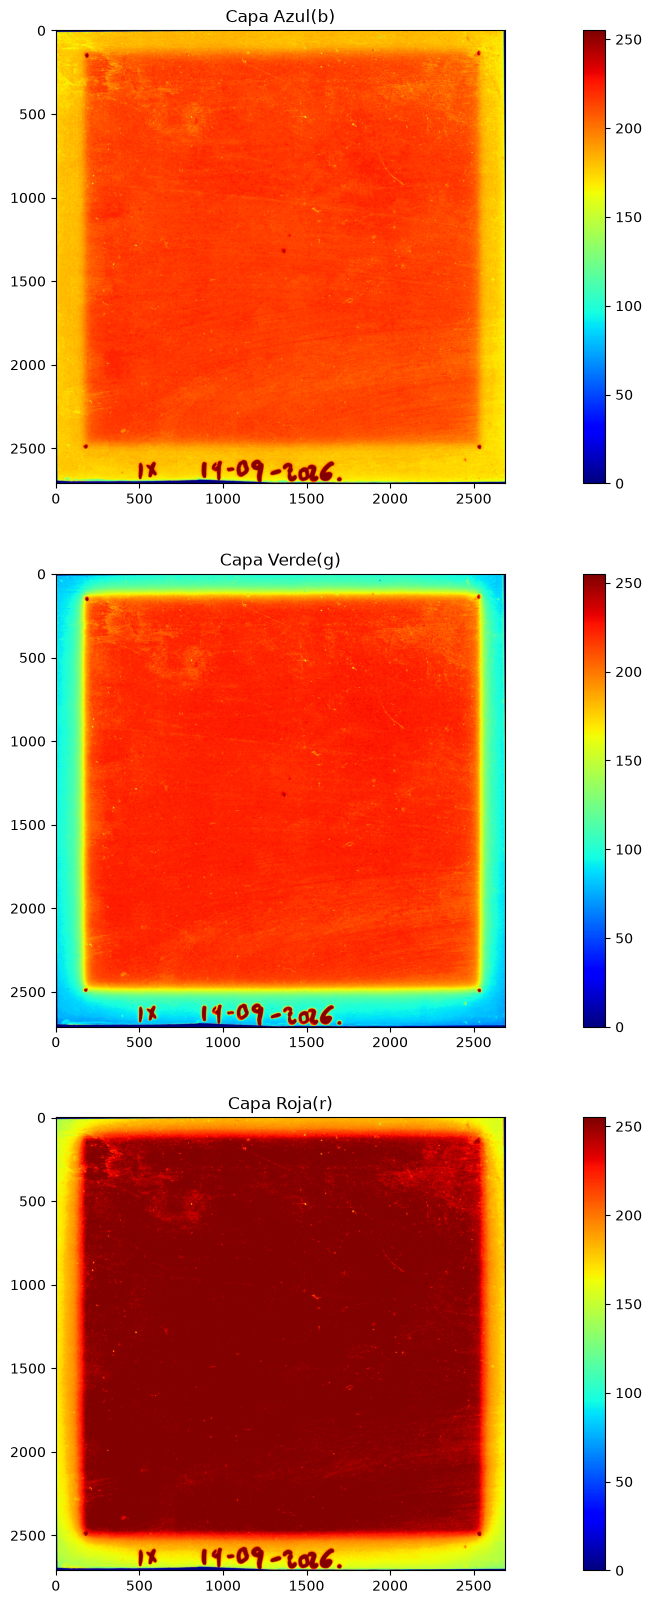

In [16]:
grosor_marco = 0

rectangulo_borde_b = cv2.rectangle(b, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)

rectangulo_borde_g = cv2.rectangle(g, (0, 0), (np.shape(g)[1], np.shape(g)[0]), 0, grosor_marco)

rectangulo_borde_r = cv2.rectangle(r, (0, 0), (np.shape(r)[1], np.shape(r)[0]), 0, grosor_marco)

plt.figure(figsize = (20, 20))

plt.subplot(3, 1, 1)
plt.imshow(rectangulo_borde_b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(rectangulo_borde_g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(rectangulo_borde_r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

El marco realmente era util para elegir mas facilmente el punto donde ibamos a escoger el valor de la pelicula virgen, el problema es que como el espectro es mas anchos sobre los perfiles que atraviesan el centro entonces el marco recorta parte de ellos, si no ponemos el marco pero elegimos el valor de la pelicula virgen ignorando un grosor equivalente al del marco como si estuviera, podemos obtener le mismo valor de la pelicula virgen sin recortar innecesariamente el borde.

In [17]:
zona_ignorada = grosor_marco + 16

valor_pelicula_b = int(rectangulo_borde_b[
    np.shape(rectangulo_borde_b)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_b)[1] - zona_ignorada
])
print(f"Valor de centro blue: {valor_pelicula_b}")

valor_pelicula_g = int(rectangulo_borde_g[
    np.shape(rectangulo_borde_g)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_g)[1] - zona_ignorada
]) 
print(f"Valor de centro green: {valor_pelicula_g}")

valor_pelicula_r = int(rectangulo_borde_r[
    np.shape(rectangulo_borde_r)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_r)[1] - zona_ignorada
])
print(f"Valor de centro red: {valor_pelicula_r}")

Valor de centro blue: 163
Valor de centro green: 69
Valor de centro red: 134


Este analisis luego se puede mejorar con lo de extraer 4 datos, uno de cada esquina, talvez mas, y sacar la mediana para encontrar el valor de la pelicula, que precauciones se tienen para garantizar que al menos un valor de las 4 esquinas o los cuatro tienen selectores que caen realemnte en una zona que corresponde a la pelicula virgen y no que, por ejemplo por la rotacion todos esos puntos quedan en el vacio.

## Acondicionamiento de la imagen

Cuanto nos vamos a separar del marco a acercar a la penumbra?:

In [18]:
np.shape(rectangulo_borde_b)

(2710, 2690)

Mientras no de cero es logico que no estamos en la region dentro del marco que es igual a cero en toda la escala de color de cada capa.

In [19]:
rectangulo_borde_b <= valor_pelicula_b

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]],
      shape=(2710, 2690))

In [20]:
int(valor_pelicula_b)

163

## Importante

Si el valor de pelicula virgen que se escoge cae en cero, pues logicamente nada va a cambiar, la intencion es ajustar borde segun el valor de la pelicula asi que el marco debe ser suficientemente grueso como para cubrir las regiones vacias de la imagen, talvez en proporcion al angulo rotado, para que el valor que se escoge un pixel hacia adentro en cada direccion sea el de la pelicula y no el del vacio.

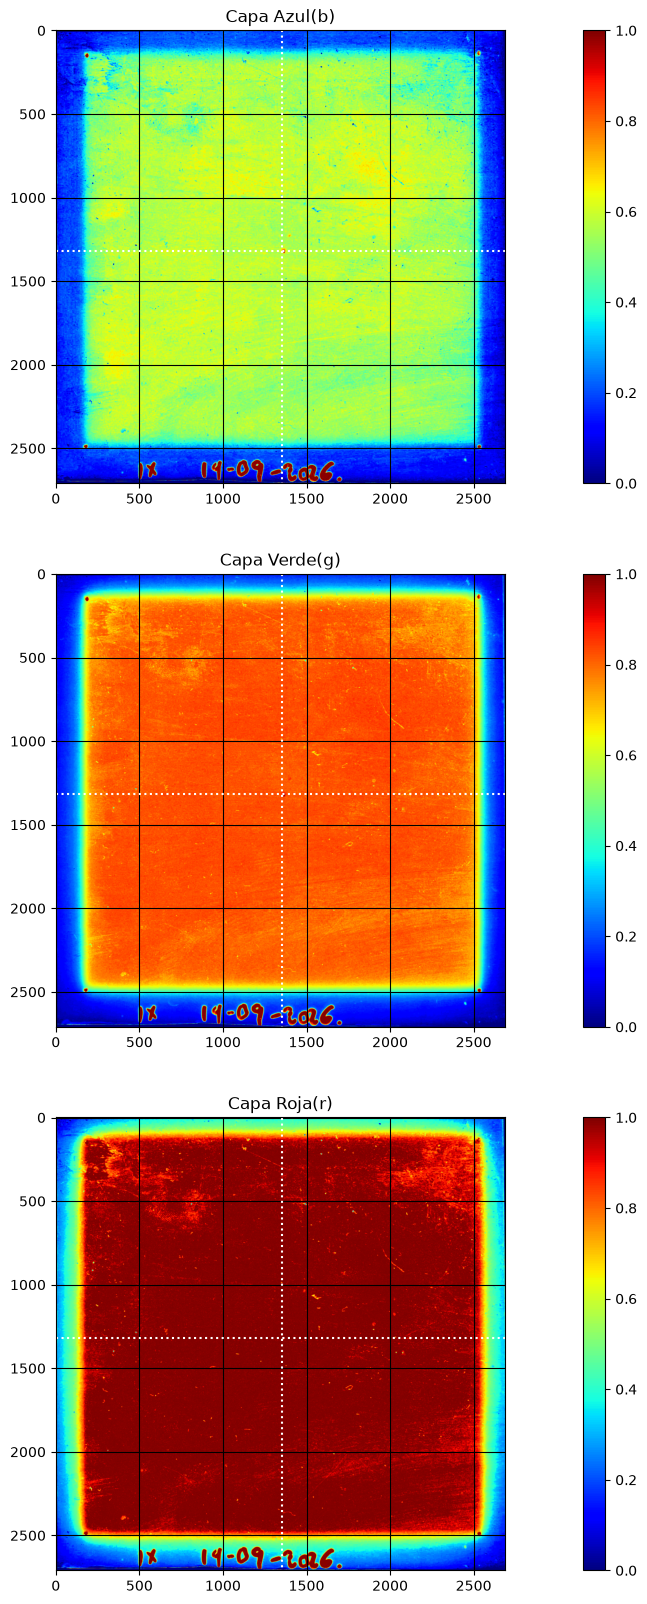

In [21]:
placa_recorte_borde_b = normalize_image(
    np.where(
        rectangulo_borde_b <= valor_pelicula_b,
        valor_pelicula_b, rectangulo_borde_b
    )
)
placa_recorte_borde_g = normalize_image(
    np.where(
        rectangulo_borde_g <= valor_pelicula_g,
        valor_pelicula_g, rectangulo_borde_g
    )
)
placa_recorte_borde_r = normalize_image(
    np.where(
        rectangulo_borde_r <= valor_pelicula_r,
        valor_pelicula_r, rectangulo_borde_r
    )
)

plt.figure(figsize = (20, 20))

plt.subplot(3, 1, 1)
plt.imshow(placa_recorte_borde_b, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_b)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_b)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(placa_recorte_borde_g, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_g)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_g)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(placa_recorte_borde_r, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_r)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_r)[1] - 1,
           colors = 'white', linestyles = ':')

plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Roja(r)')

plt.show()

Sin embargo creo que hace falta algo bastante util y es que ademas de la normalizacion debemos es normalizar respecto a el valor de la pelicula virgen, pero realmente hay alguna diferencia? ... Si dejo solo el marco y normalizo.. siento que no es lo mismo, probemos algo:

## Perfiles crossplane e inplane

In [22]:
cc_diagonales == punto_CC

False

In [23]:
np.shape(placa_recorte_borde_r)

(2710, 2690)

In [24]:
np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]

1335

Bueno, dado que el proceso de filtrado es un poco diferente, porque aqui si es importante la altura absoluta y no solo la relativa, pues debemos encontrar la altura media, por lo tanto se vuelve sumamente importante definir adecuadamente el nivel de piso, y no solo dejar el nivel de cero como el menor y no saber que valores intermedios hay y mas aun, que valor dentro de la escala normalizada corresponde al de la pelicula virgen. Y por lo tanto es que es diferente la seleccion de los intervalos para la grafica, porque despues de ese acondicionamiento podemos y debemos trabajar en todo el rango de la imagen.

De la misma forma que en el primer analisis debemos obtener la media de la meseta ignorando la zona central contaminada por el punto de marcacion. Posteriormente haremos un barrido similar al de braquiterapia para encontrar una media sobre el resto de la region.

Aparece un problema al eliminar los ceros de las periferias y escoger el siguiente valor, pues para eliminarlos lo que se esta haciendo es encontrarlos primero con un where y luego extraer el intervalo util ignorando esa seccion de cero asumiendo que es continua, es por esto que si por alguna razon hay un valor cero en el interior de la meseta, el algoritmo lo va a encontrar y va a iniciar la graficacion y el analisis desde ese valor en adelante, logicamente el problema es que recorta informacion util de la curva e inicia en un punto aleatorio posiblemente debido a ruido fotonico pero eliminando porciones vitales del perfil. Lo que se puede hacer entonces es solo tener en cuenta los ceros que se van a eliminar si estos estan fuera de la meseta, de la misma forma que solo se tiene en cuenta lo que esta dentro de la meseta para el calculo de la media.

In [25]:
extremo_meseta = 1000

excepcion_centro = 90

# utol_min = 0.1

Nos quedamos con el pergil completo, sin recortar por bordes ni nada, lo unico que hemos hecho es rellenar los vacios fuera de la placa con el valor de la pelicula, como sabemos esto? Pues porque en la funcion where se reemplazan solo los valores menores que la pelicula virgen por el valor de la pelicual virgen, los unicos valores menores son los vacios de la placa frente al escaneo, asi que lo unico que recorta los perfiles son la frontera fisica de la placa, no porque ahi exista un marco.

Vamos a probar implementando ese metodo de quedarnos con el segundo minimo entre los dos extremos para crear un piso mas confiable y automatizado en los perfiles, el problema tiene que ver con la eficiencia del codigo, porque eso se distingue facilmente una vez tenemos el perfil ya con los valores menores o iguales a cero por fuera del intervalo de interes, pero antes de esto como encontramos ese minimo, por definicion ese minimo por cada lado viene por el minimo diferente de cero:

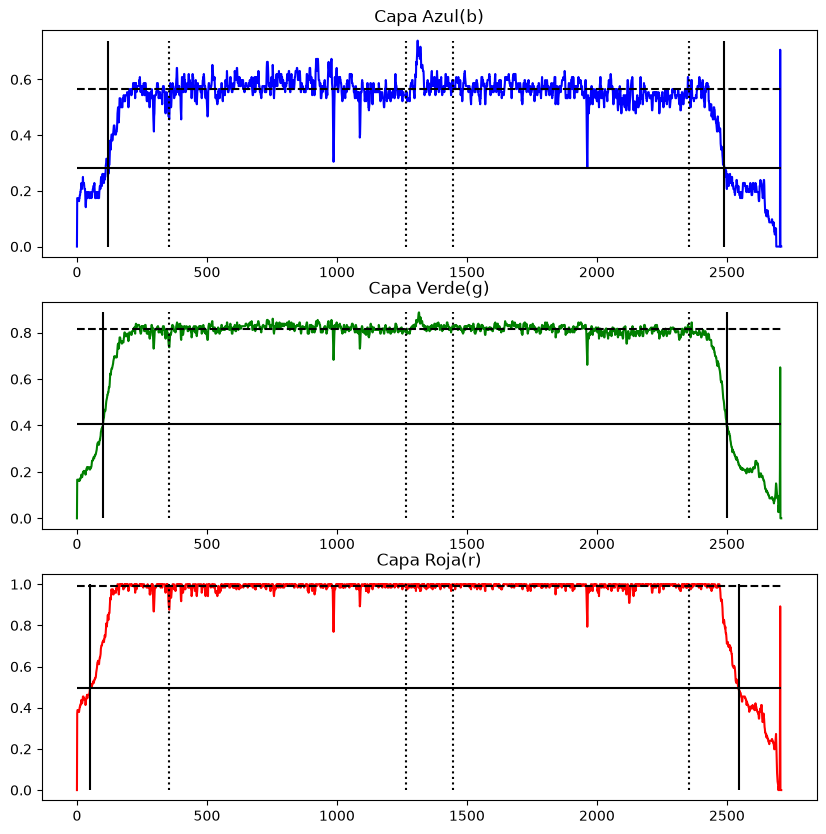

Media inplane blue: 0.5648232202580028
Media inplane green: 0.8158631690889756
Media inplane red: 0.9906184724366544
HM inplane blue: 0.2824116101290014
HM inplane green: 0.4079315845444878
HM inplane red: 0.4953092362183272


In [26]:
b_inplane= np.rot90(placa_recorte_borde_b)[
    np.shape(placa_recorte_borde_b)[1] - centro_rotacion[0]
]

g_inplane= np.rot90(placa_recorte_borde_g)[
    np.shape(placa_recorte_borde_g)[1] - centro_rotacion[0]
]

r_inplane = np.rot90(placa_recorte_borde_r)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
]


# Ese es el array del corte inplane, crudo. No se debe modificar mas
# hay que es hacer el analisis a partir de estos datos

media_inplane_b = (np.mean(
    b_inplane[
        np.shape(b_inplane)[0]//2 - extremo_meseta
        :
        np.shape(b_inplane)[0]//2 - excepcion_centro
        ]) + np.mean(b_inplane[
            np.shape(b_inplane)[0]//2 + excepcion_centro
            :
            np.shape(b_inplane)[0]//2 + extremo_meseta
            ])
) * 0.5

media_inplane_g = (np.mean(
    g_inplane[
        np.shape(g_inplane)[0]//2 - extremo_meseta
        :
        np.shape(g_inplane)[0]//2 - excepcion_centro
        ]) + np.mean(g_inplane[
            np.shape(g_inplane)[0]//2 + excepcion_centro
            :
            np.shape(g_inplane)[0]//2 + extremo_meseta
            ])
) * 0.5

media_inplane_r = (np.mean(
    r_inplane[
        np.shape(r_inplane)[0]//2 - extremo_meseta
        :
        np.shape(r_inplane)[0]//2 - excepcion_centro
        ]) + np.mean(r_inplane[
            np.shape(r_inplane)[0]//2 + excepcion_centro
            :
            np.shape(r_inplane)[0]//2 + extremo_meseta
            ])
) * 0.5

HM_b = 0.5 * (media_inplane_b + np.min(b_inplane))
HM_g = 0.5 * (media_inplane_g + np.min(g_inplane))
HM_r = 0.5 * (media_inplane_r + np.min(r_inplane))

# Cortes inplane blue
corte_1i_b = int(np.abs(
    b_inplane[
        :np.shape(b_inplane)[0]//2 - extremo_meseta
    ] - HM_b
).argmin())

corte_2i_b = int(np.abs(
    b_inplane[
        np.shape(b_inplane)[0]//2 + extremo_meseta:
    ] - HM_b
).argmin()) + extremo_meseta + np.shape(b_inplane)[0]//2

# Cortes inplane green
corte_1i_g = int(np.abs(
    g_inplane[
        :np.shape(g_inplane)[0]//2 - extremo_meseta
    ] - HM_g
).argmin())

corte_2i_g = int(np.abs(
    g_inplane[
        np.shape(g_inplane)[0]//2 + extremo_meseta:
    ] - HM_g
).argmin()) + extremo_meseta + np.shape(g_inplane)[0]//2

# Cortes inplane red
corte_1i_r = int(np.abs(
    r_inplane[
        :np.shape(r_inplane)[0]//2 - extremo_meseta
    ] - HM_r
).argmin())

corte_2i_r = int(np.abs(
    r_inplane[
        np.shape(r_inplane)[0]//2 + extremo_meseta:
    ] - HM_r
).argmin()) + extremo_meseta + np.shape(r_inplane)[0]//2


plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.plot(b_inplane, color = 'blue')

plt.vlines(np.shape(b_inplane)[0]//2 - extremo_meseta, np.min(b_inplane),
           np.max(b_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(b_inplane)[0]//2 - excepcion_centro, np.min(b_inplane),
           np.max(b_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(b_inplane)[0]//2 + excepcion_centro, np.min(b_inplane),
           np.max(b_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(b_inplane)[0]//2 + extremo_meseta, np.min(b_inplane),
           np.max(b_inplane), colors = 'black', linestyles = ':')

# Corte a la altura media
plt.vlines(corte_1i_b, np.min(b_inplane),
           np.max(b_inplane), colors = 'black', linestyles = '-')
plt.vlines(corte_2i_b, np.min(b_inplane),
           np.max(b_inplane), colors = 'black', linestyles = '-')

plt.hlines(media_inplane_b, 0, np.shape(b_inplane)[0], colors = 'black', linestyles = '--')
plt.hlines(HM_b, 0, np.shape(b_inplane)[0], colors = 'black', linestyles = '-')

plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.plot(g_inplane, color = 'green')

plt.vlines(np.shape(g_inplane)[0]//2 - extremo_meseta, np.min(g_inplane),
           np.max(g_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(g_inplane)[0]//2 - excepcion_centro, np.min(g_inplane),
           np.max(g_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(g_inplane)[0]//2 + excepcion_centro, np.min(g_inplane),
           np.max(g_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(g_inplane)[0]//2 + extremo_meseta, np.min(g_inplane),
           np.max(g_inplane), colors = 'black', linestyles = ':')

# Corte a la altura media
plt.vlines(corte_1i_g, np.min(g_inplane),
           np.max(g_inplane), colors = 'black', linestyles = '-')
plt.vlines(corte_2i_g, np.min(g_inplane),
           np.max(g_inplane), colors = 'black', linestyles = '-')

plt.hlines(media_inplane_g, 0, np.shape(g_inplane)[0], colors = 'black', linestyles = '--')
plt.hlines(HM_g, 0, np.shape(g_inplane)[0], colors = 'black', linestyles = '-')

plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.plot(r_inplane, color = 'red')

plt.vlines(np.shape(r_inplane)[0]//2 - extremo_meseta, np.min(r_inplane),
           np.max(r_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(r_inplane)[0]//2 - excepcion_centro, np.min(r_inplane),
           np.max(r_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(r_inplane)[0]//2 + excepcion_centro, np.min(r_inplane),
           np.max(r_inplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(r_inplane)[0]//2 + extremo_meseta, np.min(r_inplane),
           np.max(r_inplane), colors = 'black', linestyles = ':')

# COrte a la altura media
plt.vlines(corte_1i_r, np.min(r_inplane),
           np.max(r_inplane), colors = 'black', linestyles = '-')
plt.vlines(corte_2i_r, np.min(r_inplane),
           np.max(r_inplane), colors = 'black', linestyles = '-')

plt.hlines(media_inplane_r, 0, np.shape(r_inplane)[0], colors = 'black', linestyles = '--')
plt.hlines(HM_r, 0, np.shape(r_inplane)[0], colors = 'black', linestyles = '-')

plt.title('Capa Roja(r)')

plt.show()

print(f"Media inplane blue: {media_inplane_b}")
print(f"Media inplane green: {media_inplane_g}")
print(f"Media inplane red: {media_inplane_r}")

print(f"HM inplane blue: {HM_b}")
print(f"HM inplane green: {HM_g}")
print(f"HM inplane red: {HM_r}")

Es por las fronteras fisicas de la placa que se recortan asimetricamente los perfiles por capa de color inplane, porque como vemos son mas anchas hacia abajo que hacia arriba respecto al centro de irradiacion.

Creo que las letras no afectan para encontrar la interseccion entre la linea de media altura con la curva, porque inevitablemente los valores de la penumbra van a estar mucho mas cerca siempre que los valores oscuros de la tinta del marcador, por lo cual cuando se hace el reconocimiento con el minimo argumento no hay valores realmente en esa zona por parte de las letras asi la curva parezca continua.

Vemos que aqui la mayoria del ruido es generado por el texto que contiene la placa para su identificacion, igual podemos usar las mismas tecnicas que en la version anterior del analisis para ignorar ciertas regiones en el analisis.

Creo que podemos en caso de querer recortar un poco mas el piso pero sin depender de un umbral arbitrario, seleccionar como piso el punto minimo mas grande entre los dos extremos de cada perfil.

Ahora si entonces busquemos esos puntos de interseccion con la altura media.

Bueno el calculo sucedio apropiadamente, deberia igual recomendarse escribir siempre el texto con el mismo marcador oscuro de siempre, entre mas traslucido sea mas probable es que baje el gradiente y los puntos se acercen a los valores de la penumbra cerca de la altura media.

### FWHM Inplane

Ahora con las posiciones simplemente debemos hacer la resta y convertir a milimetros.

In [27]:
print(f"Posiciones corte blue(b):({corte_1i_b}, {corte_2i_b})")
print(f"Posiciones corte blue(g):({corte_1i_g}, {corte_2i_g})")
print(f"Posiciones corte blue(r):({corte_1i_r}, {corte_2i_r})")

Posiciones corte blue(b):(120, 2490)
Posiciones corte blue(g):(100, 2499)
Posiciones corte blue(r):(50, 2545)


In [28]:
FWHM_b = (corte_2i_b - corte_1i_b) * tamano_pixel
FWHM_g = (corte_2i_g - corte_1i_g) * tamano_pixel
FWHM_r = (corte_2i_r - corte_1i_r) * tamano_pixel

print(f"FWHM blue(b): {np.round(FWHM_b, 3)} mm")
print(f"FWHM Green(g): {np.round(FWHM_g, 3)} mm")
print(f"FWHM Red(r): {np.round(FWHM_r, 3)} mm")

FWHM blue(b): 100.33 mm
FWHM Green(g): 101.558 mm
FWHM Red(r): 105.622 mm


Es importante tener en cuenta que la funcion de normalizar, tal como debe ser, no deforma la curva para suavizarla respecto al nivel de la placa, simplemente mete todos los valores conservando su forma y gradiente entre cero y uno, por lo cual si hay cortes o saltos a cero desde valores intermedios los seguira habiendo luego de la normalizacion. Por lo tanto para eliminar estos valores simplemente ignoramos las regiones donde el perfil es igual a cero.

## Perfil crossplane

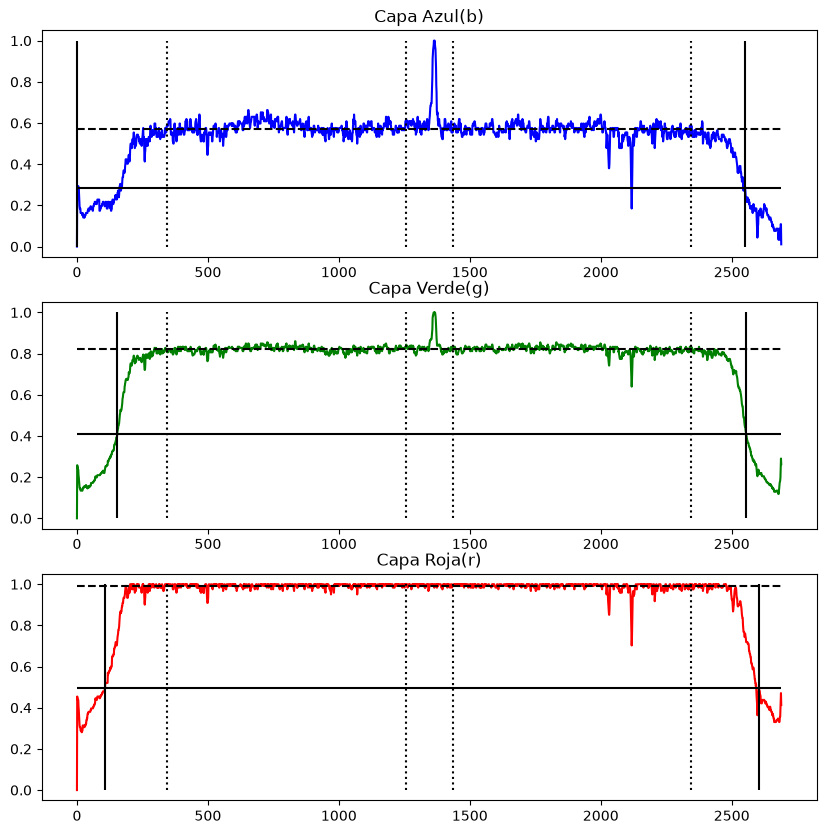

Media crossplane blue: 0.5713091256569516
Media crossplane green: 0.8211390759777856
Media crossplane red: 0.9909545000454092
HM crossplane blue: 0.2856545628284758
HM crossplane green: 0.4105695379888928
HM crossplane red: 0.4954772500227046


In [29]:
b_crossplane = placa_recorte_borde_b[
    centro_rotacion[1]
]

g_crossplane = placa_recorte_borde_g[
    centro_rotacion[1]
]


r_crossplane= placa_recorte_borde_r[
    centro_rotacion[1]
]

# Ese es el array del corte inplane, crudo. No se debe modificar mas
# hay que es hacer el analisis a partir de estos datos

media_crossplane_b = (np.mean(
    b_crossplane[
        np.shape(b_crossplane)[0]//2 - extremo_meseta
        :
        np.shape(b_crossplane)[0]//2 - excepcion_centro
        ]) + np.mean(b_crossplane[
            np.shape(b_crossplane)[0]//2 + excepcion_centro
            :
            np.shape(b_crossplane)[0]//2 + extremo_meseta
            ])
) * 0.5

media_crossplane_g = (np.mean(
    g_crossplane[
        np.shape(g_crossplane)[0]//2 - extremo_meseta
        :
        np.shape(g_crossplane)[0]//2 - excepcion_centro
        ]) + np.mean(g_crossplane[
            np.shape(g_crossplane)[0]//2 + excepcion_centro
            :
            np.shape(g_crossplane)[0]//2 + extremo_meseta
            ])
) * 0.5

media_crossplane_r = (np.mean(
        r_crossplane[
            np.shape(r_crossplane)[0]//2 - extremo_meseta
            :
            np.shape(r_crossplane)[0]//2 - excepcion_centro
            ]) + np.mean(r_crossplane[
                np.shape(r_crossplane)[0]//2 + excepcion_centro
                :
                np.shape(r_crossplane)[0]//2 + extremo_meseta
                ])
) * 0.5

HM_crossplane_b = 0.5 * (media_crossplane_b + np.min(b_crossplane))
HM_crossplane_g = 0.5 * (media_crossplane_g + np.min(g_crossplane))
HM_crossplane_r = 0.5 * (media_crossplane_r + np.min(r_crossplane))

# Cortes inplane blue
corte_1c_b = int(np.abs(
    b_crossplane[
        :np.shape(b_crossplane)[0]//2 - extremo_meseta
    ] - HM_crossplane_b
).argmin())

corte_2c_b = int(np.abs(
    b_crossplane[
        np.shape(b_crossplane)[0]//2 + extremo_meseta:
    ] - HM_crossplane_b
).argmin()) + extremo_meseta + np.shape(b_crossplane)[0]//2

# Cortes inplane green
corte_1c_g = int(np.abs(
    g_crossplane[
        :np.shape(g_crossplane)[0]//2 - extremo_meseta
    ] - HM_crossplane_g
).argmin())

corte_2c_g = int(np.abs(
    g_crossplane[
        np.shape(g_crossplane)[0]//2 + extremo_meseta:
    ] - HM_crossplane_g
).argmin()) + extremo_meseta + np.shape(g_crossplane)[0]//2

# Cortes inplane red
corte_1c_r = int(np.abs(
    r_crossplane[
        :np.shape(r_crossplane)[0]//2 - extremo_meseta
    ] - HM_crossplane_r
).argmin())

corte_2c_r = int(np.abs(
    r_crossplane[
        np.shape(r_crossplane)[0]//2 + extremo_meseta:
    ] - HM_crossplane_r
).argmin()) + extremo_meseta + np.shape(r_crossplane)[0]//2


plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.plot(b_crossplane, color = 'blue')

plt.vlines(np.shape(b_crossplane)[0]//2 - extremo_meseta, np.min(b_crossplane),
           np.max(b_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(b_crossplane)[0]//2 - excepcion_centro, np.min(b_crossplane),
           np.max(b_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(b_crossplane)[0]//2 + excepcion_centro, np.min(b_crossplane),
           np.max(b_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(b_crossplane)[0]//2 + extremo_meseta, np.min(b_crossplane),
           np.max(b_crossplane), colors = 'black', linestyles = ':')

# Corte a la altura media
plt.vlines(corte_1c_b, np.min(b_crossplane),
           np.max(b_crossplane), colors = 'black', linestyles = '-')
plt.vlines(corte_2c_b, np.min(b_crossplane),
           np.max(b_crossplane), colors = 'black', linestyles = '-')

plt.hlines(media_crossplane_b, 0, np.shape(b_crossplane)[0], colors = 'black', linestyles = '--')
plt.hlines(HM_crossplane_b, 0, np.shape(b_crossplane)[0], colors = 'black', linestyles = '-')

plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.plot(g_crossplane, color = 'green')

plt.vlines(np.shape(g_crossplane)[0]//2 - extremo_meseta, np.min(g_crossplane),
           np.max(g_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(g_crossplane)[0]//2 - excepcion_centro, np.min(g_crossplane),
           np.max(g_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(g_crossplane)[0]//2 + excepcion_centro, np.min(g_crossplane),
           np.max(g_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(g_crossplane)[0]//2 + extremo_meseta, np.min(g_crossplane),
           np.max(g_crossplane), colors = 'black', linestyles = ':')

# Corte a la altura media
plt.vlines(corte_1c_g, np.min(g_crossplane),
           np.max(g_crossplane), colors = 'black', linestyles = '-')
plt.vlines(corte_2c_g, np.min(g_crossplane),
           np.max(g_crossplane), colors = 'black', linestyles = '-')

plt.hlines(media_crossplane_g, 0, np.shape(g_crossplane)[0], colors = 'black', linestyles = '--')
plt.hlines(HM_crossplane_g, 0, np.shape(g_crossplane)[0], colors = 'black', linestyles = '-')

plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.plot(r_crossplane, color = 'red')

plt.vlines(np.shape(r_crossplane)[0]//2 - extremo_meseta, np.min(r_crossplane),
           np.max(r_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(r_crossplane)[0]//2 - excepcion_centro, np.min(r_crossplane),
           np.max(r_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(r_crossplane)[0]//2 + excepcion_centro, np.min(r_crossplane),
           np.max(r_crossplane), colors = 'black', linestyles = ':')
plt.vlines(np.shape(r_crossplane)[0]//2 + extremo_meseta, np.min(r_crossplane),
           np.max(r_crossplane), colors = 'black', linestyles = ':')

# COrte a la altura media
plt.vlines(corte_1c_r, np.min(r_crossplane),
           np.max(r_crossplane), colors = 'black', linestyles = '-')
plt.vlines(corte_2c_r, np.min(r_crossplane),
           np.max(r_crossplane), colors = 'black', linestyles = '-')

plt.hlines(media_crossplane_r, 0, np.shape(r_crossplane)[0], colors = 'black', linestyles = '--')
plt.hlines(HM_crossplane_r, 0, np.shape(r_crossplane)[0], colors = 'black', linestyles = '-')

plt.title('Capa Roja(r)')

plt.show()

print(f"Media crossplane blue: {media_crossplane_b}")
print(f"Media crossplane green: {media_crossplane_g}")
print(f"Media crossplane red: {media_crossplane_r}")

print(f"HM crossplane blue: {HM_crossplane_b}")
print(f"HM crossplane green: {HM_crossplane_g}")
print(f"HM crossplane red: {HM_crossplane_r}")

In [30]:
np.min(r_crossplane)

np.float64(0.0)

Depronto mejore la calidad del perfil y por tanto del analisis crear un umbral minimo para los perfiles, no, eso es recortar informacion que porta la placa solo para ajustar la curva al resultado ideal. 

Puede que no sea finalmente tan importante el recorte que sufren los perfiles por los limites fisicos de la superficie de la placa puesto que nuestro piso es confiable, y mientras nuestro piso sea el valor de la pelicula virgen solo importa tener el maximo y el punto donde corta a la media altura, por lo cual, no hay datos necesarios faltantes. A no ser de que se desee medir el ancho total de la penumbra o el area total bajo la curva o cosas que necesiten el perfil completo.

### FWHM Crossplane

Pero con la modificacion que hicimos de recortar el rango realmente estamos tomando el valor adecuado de pixel apra el calculo del FWHM? Pues parece que si, porque el grafico y los calculos los estamos haciendo es sobre el intervalo ya recortado, la diferencia no necesita posisicon absoluta, solo es la distancia, que es una cantidad de pixeles, entre un punto y otro de ese intervalo.

In [31]:
print(f"Posiciones corte blue(b):({corte_1c_b}, {corte_2c_b})")
print(f"Posiciones corte blue(g):({corte_1c_g}, {corte_2c_g})")
print(f"Posiciones corte blue(r):({corte_1c_r}, {corte_2c_r})")

Posiciones corte blue(b):(2, 2550)
Posiciones corte blue(g):(154, 2555)
Posiciones corte blue(r):(107, 2604)


In [32]:
FWHM_crossplane_b = (corte_2c_b - corte_1c_b) * tamano_pixel
FWHM_crossplane_g = (corte_2c_g - corte_1c_g) * tamano_pixel
FWHM_crossplane_r = (corte_2c_r - corte_1c_r) * tamano_pixel

print(f"FWHM blue(b): {np.round(FWHM_crossplane_b, 3)} mm")
print(f"FWHM Green(g): {np.round(FWHM_crossplane_g, 3)} mm")
print(f"FWHM Red(r): {np.round(FWHM_crossplane_r, 3)} mm")

FWHM blue(b): 107.865 mm
FWHM Green(g): 101.642 mm
FWHM Red(r): 105.706 mm


## Barrido en cada direccion

El barrido se va a hacer dentro del area que se selecciono para calcular la media, como para estandarizar todo el proceso pues.

### Barrido Inplane

In [33]:
delta_tol = 100 # mm
desviacion_tol = 0.05

ancho_barrido = 2 * extremo_meseta

Parece que realemnte es inproductivo hacer todo ese acondicionamiento de imagen para luego solo recortar todo por fuera de la curva con ese where, ahora que lo pienso esto... es mentir? Porque estor descartando datos que contiene la imagen solamente porque la curva no tiene la forma ideal que yo estoy esperando ver, entonces asi de peor, parece que el metodo correcto incluye medir la curva virgen sabiendo que ya habia garantizado el piso con los procesos de acondicionamiento de la imagen, donde se tapan los bordes. luego todo se vuelve igual aproximadamente a la pelicula virgen (Que creo ahora que se puede elegir facilmente de forma manual con un 6 punto marcado, lo cual puede aportar versatilidad) y luego volviendo esto el piso, lo cual es justamente lo que se espera sacar de la pelicula, recortar aun mas el piso para darle mejor forma a la curva parece un truco simplemente, a no ser de que lo que se este viendo en los perfiles sea ruido inducido por la forma de abrir y construir los perfiles, porque igual si es ruido que contiene la placa o el escaner, etc, entonces pues no es razon para modificar el codigo. 

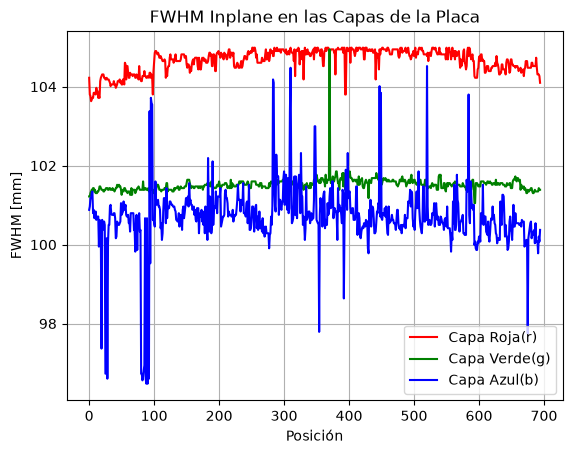

In [34]:
FWHM_ivals_b = []
FWHM_ivals_g = []
FWHM_ivals_r = []

for o in range(centro_rotacion[1] - ancho_barrido//2, centro_rotacion[1] + ancho_barrido//2):

    b_inplane = np.rot90(placa_recorte_borde_b)[
        np.shape(placa_recorte_borde_b)[1] - int(o)
    ]

    g_inplane = np.rot90(placa_recorte_borde_g)[
        np.shape(placa_recorte_borde_g)[1] - int(o)
    ]

    r_inplane = np.rot90(placa_recorte_borde_r)[
        np.shape(placa_recorte_borde_r)[1] - int(o)
    ]

    # Ese es el array del corte inplane, crudo. No se debe modificar mas
    # hay que es hacer el analisis a partir de estos datos

    media_inplane_b = (np.mean(
        b_inplane[
            np.shape(b_inplane)[0]//2 - extremo_meseta
            :
            np.shape(b_inplane)[0]//2 - excepcion_centro
            ]) + np.mean(b_inplane[
                np.shape(b_inplane)[0]//2 + excepcion_centro
                :
                np.shape(b_inplane)[0]//2 + extremo_meseta
                ])
    ) * 0.5

    media_inplane_g = (np.mean(
        g_inplane[
            np.shape(g_inplane)[0]//2 - extremo_meseta
            :
            np.shape(g_inplane)[0]//2 - excepcion_centro
            ]) + np.mean(g_inplane[
                np.shape(g_inplane)[0]//2 + excepcion_centro
                :
                np.shape(g_inplane)[0]//2 + extremo_meseta
                ])
    ) * 0.5

    media_inplane_r = (np.mean(
        r_inplane[
            np.shape(r_inplane)[0]//2 - extremo_meseta
            :
            np.shape(r_inplane)[0]//2 - excepcion_centro
            ]) + np.mean(r_inplane[
                np.shape(r_inplane)[0]//2 + excepcion_centro
                :
                np.shape(r_inplane)[0]//2 + extremo_meseta
                ])
    ) * 0.5

    HM_b = 0.5 * (media_inplane_b + np.min(b_inplane))
    HM_g = 0.5 * (media_inplane_g + np.min(g_inplane))
    HM_r = 0.5 * (media_inplane_r + np.min(r_inplane))

    # Cortes inplane blue
    corte_1i_b = int(np.abs(
        b_inplane[
            :np.shape(b_inplane)[0]//2 - excepcion_centro
        ] - HM_b
    ).argmin())

    corte_2i_b = int(np.abs(
        b_inplane[
            np.shape(b_inplane)[0]//2 + excepcion_centro:
        ] - HM_b
    ).argmin()) + excepcion_centro + np.shape(b_inplane)[0]//2

    # Cortes inplane green
    corte_1i_g = int(np.abs(
        g_inplane[
            :np.shape(g_inplane)[0]//2 - excepcion_centro
        ] - HM_g
    ).argmin())

    corte_2i_g = int(np.abs(
        g_inplane[
            np.shape(g_inplane)[0]//2 + excepcion_centro:
        ] - HM_g
    ).argmin()) + excepcion_centro + np.shape(g_inplane)[0]//2

    # Cortes inplane red
    corte_1i_r = int(np.abs(
        r_inplane[
            :np.shape(r_inplane)[0]//2 - excepcion_centro
        ] - HM_r
    ).argmin())

    corte_2i_r = int(np.abs(
        r_inplane[
            np.shape(r_inplane)[0]//2 + excepcion_centro:
        ] - HM_r
    ).argmin()) + excepcion_centro + np.shape(r_inplane)[0]//2

    FWHM_inplane_b = (corte_2i_b - corte_1i_b) * tamano_pixel
    FWHM_inplane_g = (corte_2i_g - corte_1i_g) * tamano_pixel
    FWHM_inplane_r = (corte_2i_r - corte_1i_r) * tamano_pixel

    # Tienen que ser los 3 array del mismo tamano?
    
    if (1 - desviacion_tol) * delta_tol <= FWHM_inplane_b <= delta_tol * (1 + desviacion_tol) and (1 - desviacion_tol) * delta_tol <= FWHM_inplane_g <= delta_tol * (1 + desviacion_tol) and (1 - desviacion_tol) * delta_tol <= FWHM_inplane_r <= delta_tol * (1 + desviacion_tol):

        FWHM_ivals_b.append(FWHM_inplane_b)
        FWHM_ivals_g.append(FWHM_inplane_g)
        FWHM_ivals_r.append(FWHM_inplane_r)

plt.plot(FWHM_ivals_r, color = 'red', label = 'Capa Roja(r)')
plt.plot(FWHM_ivals_g, color = 'green', label = 'Capa Verde(g)')
plt.plot(FWHM_ivals_b, color = 'blue', label = 'Capa Azul(b)')
plt.xlabel('Posición')
plt.ylabel('FWHM [mm]')
plt.title('FWHM Inplane en las Capas de la Placa')
plt.legend()
plt.grid()
plt.show()

### Barrido Crossplane

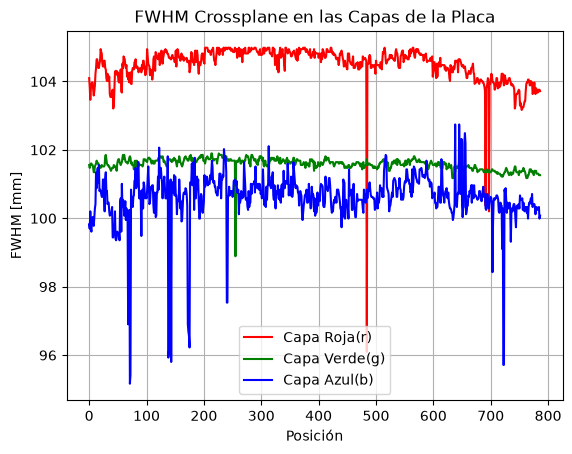

In [35]:
FWHM_cvals_b = []
FWHM_cvals_g = []
FWHM_cvals_r = []

for i in range(centro_rotacion[1] - ancho_barrido//2, centro_rotacion[1] + ancho_barrido//2):

    b_crossplane = placa_recorte_borde_b[
        int(i)
    ]

    g_crossplane = placa_recorte_borde_g[
        int(i)
    ]

    r_crossplane = placa_recorte_borde_r[
        int(i)
    ]

    # Ese es el array del corte inplane, crudo. No se debe modificar mas
    # hay que es hacer el analisis a partir de estos datos

    media_crossplane_b = (np.mean(
        b_crossplane[
            np.shape(b_crossplane)[0]//2 - extremo_meseta
            :
            np.shape(b_crossplane)[0]//2 - excepcion_centro
            ]) + np.mean(b_crossplane[
                np.shape(b_crossplane)[0]//2 + excepcion_centro
                :
                np.shape(b_crossplane)[0]//2 + extremo_meseta
                ])
    ) * 0.5

    HM_crossplane_b = 0.5 * (media_crossplane_b + np.min(b_crossplane))

    media_crossplane_g = (np.mean(
        g_crossplane[
            np.shape(g_crossplane)[0]//2 - extremo_meseta
            :
            np.shape(g_crossplane)[0]//2 - excepcion_centro
            ]) + np.mean(g_crossplane[
                np.shape(g_crossplane)[0]//2 + excepcion_centro
                :
                np.shape(g_crossplane)[0]//2 + extremo_meseta
                ])
    ) * 0.5

    HM_crossplane_g = 0.5 * (media_crossplane_g + np.min(g_crossplane))

    media_crossplane_r = (np.mean(
            r_crossplane[
                np.shape(r_crossplane)[0]//2 - extremo_meseta
                :
                np.shape(r_crossplane)[0]//2 - excepcion_centro
                ]) + np.mean(r_crossplane[
                    np.shape(r_crossplane)[0]//2 + excepcion_centro
                    :
                    np.shape(r_crossplane)[0]//2 + extremo_meseta
                    ])
    ) * 0.5

    HM_crossplane_r = 0.5 * (media_crossplane_r + np.min(r_crossplane))

    # Cortes inplane blue
    corte_1c_b = int(np.abs(
        b_crossplane[
            :np.shape(b_crossplane)[0]//2 - excepcion_centro
        ] - HM_crossplane_b
    ).argmin())

    corte_2c_b = int(np.abs(
        b_crossplane[
            np.shape(b_crossplane)[0]//2 + excepcion_centro:
        ] - HM_crossplane_b
    ).argmin()) + excepcion_centro + np.shape(b_crossplane)[0]//2

    # Cortes inplane green
    corte_1c_g = int(np.abs(
        g_crossplane[
            :np.shape(g_crossplane)[0]//2 - excepcion_centro
        ] - HM_crossplane_g
    ).argmin())

    corte_2c_g = int(np.abs(
        g_crossplane[
            np.shape(g_crossplane)[0]//2 + excepcion_centro:
        ] - HM_crossplane_g
    ).argmin()) + excepcion_centro + np.shape(g_crossplane)[0]//2

    # Cortes inplane red
    corte_1c_r = int(np.abs(
        r_crossplane[
            :np.shape(r_crossplane)[0]//2 - excepcion_centro
        ] - HM_crossplane_r
    ).argmin())

    corte_2c_r = int(np.abs(
        r_crossplane[
            np.shape(r_crossplane)[0]//2 + excepcion_centro:
        ] - HM_crossplane_r
    ).argmin()) + excepcion_centro + np.shape(r_crossplane)[0]//2

    FWHM_crossplane_b = (corte_2c_b - corte_1c_b) * tamano_pixel
    FWHM_crossplane_g = (corte_2c_g - corte_1c_g) * tamano_pixel
    FWHM_crossplane_r = (corte_2c_r - corte_1c_r) * tamano_pixel

    # Tienen que ser los 3 array del mismo tamano?
    
    if (1 - desviacion_tol) * delta_tol <= FWHM_crossplane_b <= delta_tol * (1 + desviacion_tol) and (1 - desviacion_tol) * delta_tol <= FWHM_crossplane_g <= delta_tol * (1 + desviacion_tol) and (1 - desviacion_tol) * delta_tol <= FWHM_crossplane_r <= delta_tol * (1 + desviacion_tol):

        FWHM_cvals_b.append(FWHM_crossplane_b)
        FWHM_cvals_g.append(FWHM_crossplane_g)
        FWHM_cvals_r.append(FWHM_crossplane_r)

plt.plot(FWHM_cvals_r, color = 'red', label = 'Capa Roja(r)')
plt.plot(FWHM_cvals_g, color = 'green', label = 'Capa Verde(g)')
plt.plot(FWHM_cvals_b, color = 'blue', label = 'Capa Azul(b)')
plt.xlabel('Posición')
plt.ylabel('FWHM [mm]')
plt.title('FWHM Crossplane en las Capas de la Placa')
plt.legend()
plt.grid()
plt.show()

### Importante

Esta pasando algo que complica bastante el analisis a nivel general porque parece que los pisos de los 3 perfiles no coinciden. Cuando no aplico el rectangulo funciona superbien cuando no hay artefactos generados por los bordes, pero en zonas alejadas del centro, empiezan a aparecer, justamente porque se ve el fondo a traves de la imagen, esto logicamente se solucionar facil con generar el marco rectangular y dandole un valor igual al minimo de la penumbra, no se si el fallo ha sido que no se ha seleccionado adecuadamente ese valor, sino que esta cayendo en uno mucho mas bajo y por eso genera un piso tan inferior.

El resto del ajuste podria venir por simplemente definir el minimo valor diferente a cero.

## Coincidencia con el campo luminoso

Ahora simplemente debemos definir respecto al punto de FWHM como esta de alejado el punto por donde cruza la linea de campo luminoso trazada segun las esquinas.

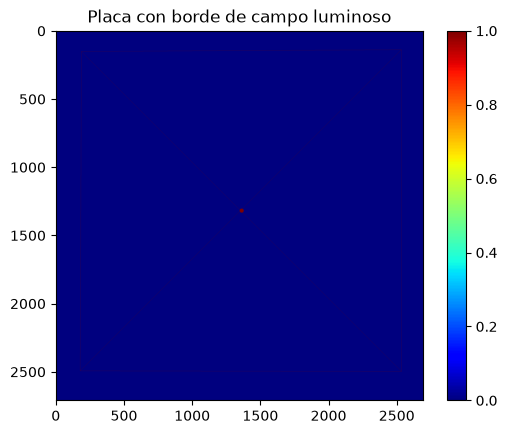

In [36]:
fondo_rotado = np.zeros(np.shape(placa_analizada_gray))

valor_trazos = 1
grosor_trazo = 1

cv2.line(fondo_rotado, punto_UL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(fondo_rotado, punto_UL, punto_DL, valor_trazos, grosor_trazo)
cv2.line(fondo_rotado, punto_UL, punto_DR, valor_trazos, grosor_trazo)
cv2.line(fondo_rotado, punto_DL, punto_UR, valor_trazos, grosor_trazo)
cv2.line(fondo_rotado, punto_UR, punto_DR, valor_trazos, grosor_trazo)
cv2.line(fondo_rotado, punto_DL, punto_DR, valor_trazos, grosor_trazo)

# cv2.circle(fondo, (int(np.round(x_0, 0)), int(np.round(y_0, 0))), 15, color = 1, thickness = -1)
cv2.circle(fondo_rotado, punto_CC, 15, color = 1, thickness = -1)

plt.imshow(fondo_rotado, cmap = 'jet')
plt.title("Placa con borde de campo luminoso")
plt.colorbar()
plt.show()

Bueno, aqui simplemente hay que encontrar los puntos donde el trazado de las lineas de la imagen anterior tiene valores equivalentes a 1 que es el valor de la linea, de ancho 1, por lo cual para cada corte, identico al que se hace para cada perfil crossplane e inplane, restringiendo el centro pues debe haber un solo punto igual a 1 entre el extremo de la imagen y la frontera de exclusion del centro.

Pero ojo, ese grafico que usamos que es el primero del campo luminoso que construimos esta hecho con las coordenadas de las esquinas y el centro previas a la rotacion, y todo lo demas esta calculado a partir de la imagen ya rotada, por lo cual debemos construir nuevamente el plano del cuadrilatero.

In [37]:
LS = int(np.where(fondo_rotado[
    centro_rotacion[1]
][
    :
    np.shape(fondo_rotado)[0]//2 - excepcion_centro 
] == 1)[0][0])

RS = int(np.where(fondo_rotado[
    centro_rotacion[1]
][np.shape(placa_recorte_borde_b)[0]//2 + excepcion_centro
    :
] == 1)[0][0]) + np.shape(placa_recorte_borde_r)[0]//2 + excepcion_centro

US = int(np.where(np.rot90(fondo_rotado)[
    np.shape(placa_recorte_borde_b)[0] - centro_rotacion[0]
][
    :
    np.shape(placa_recorte_borde_b)[0]//2 - excepcion_centro 
] == 1)[0][0])

DS = int(np.where(np.rot90(fondo_rotado)[
    np.shape(placa_recorte_borde_b)[0] - centro_rotacion[0]
][np.shape(placa_recorte_borde_b)[0]//2 + excepcion_centro
    : 
] == 1)[0][0]) + np.shape(placa_recorte_borde_b)[0]//2 + excepcion_centro

desfase_Lb = LS - corte_1c_b
desfase_Lg = LS - corte_1c_g
desfase_Lr = LS - corte_1c_r

desfase_Rb = RS - corte_2c_b
desfase_Rg = RS - corte_2c_g
desfase_Rr = RS - corte_2c_r

desfase_Ub = US - corte_1i_b
desfase_Ug = US - corte_1i_g
desfase_Ur = US - corte_1i_r

desfase_Db = DS - corte_2i_b
desfase_Dg = DS - corte_2i_g
desfase_Dr = DS - corte_2i_r


print("Desfase placa Azul(b)")
print(f"Desfase Lado izquierdo: {np.round(desfase_Lb * tamano_pixel, 3)} mm")
print(f"Desfase lado derecho: {np.round(desfase_Rb * tamano_pixel, 3)} mm")
print(f"Desfase lado superior: {np.round(desfase_Ub * tamano_pixel, 3)} mm")
print(f"Desfase lado inferior: {np.round(desfase_Db * tamano_pixel, 3)} mm")

print("Desfase placa Verde(g)")
print(f"Desfase Lado izquierdo: {np.round(desfase_Lg * tamano_pixel, 3)} mm")
print(f"Desfase lado derecho: {np.round(desfase_Rg * tamano_pixel, 3)} mm")
print(f"Desfase lado superior: {np.round(desfase_Ug * tamano_pixel, 3)} mm")
print(f"Desfase lado inferior: {np.round(desfase_Dg * tamano_pixel, 3)} mm")

print("Desfase placa Rojo(r)")
print(f"Desfase Lado izquierdo: {np.round(desfase_Lr * tamano_pixel, 3)} mm")
print(f"Desfase lado derecho: {np.round(desfase_Rr * tamano_pixel, 3)} mm")
print(f"Desfase lado superior: {np.round(desfase_Ur * tamano_pixel, 3)} mm")
print(f"Desfase lado inferior: {np.round(desfase_Dr * tamano_pixel, 3)} mm")

Desfase placa Azul(b)
Desfase Lado izquierdo: 0.804 mm
Desfase lado derecho: 0.212 mm
Desfase lado superior: 1.482 mm
Desfase lado inferior: 0.593 mm
Desfase placa Verde(g)
Desfase Lado izquierdo: 1.143 mm
Desfase lado derecho: -0.635 mm
Desfase lado superior: 1.99 mm
Desfase lado inferior: 0.085 mm
Desfase placa Rojo(r)
Desfase Lado izquierdo: 2.455 mm
Desfase lado derecho: -1.778 mm
Desfase lado superior: 3.556 mm
Desfase lado inferior: -1.058 mm


## Analsis en escala de grises

Segun he visto simplemente un analisis en escala de grises no es apropiado, pues promediar los valores de cada capa de colores elimina la informacion util que se puede discriminar segun la dosis de radiacion entregada sobre la pelicula y el color particular que se analiza segun esa dosis. El problema es ahora si hay que hacer algun tipo de correccion frente al desplazamiento del escaner o algo asi.

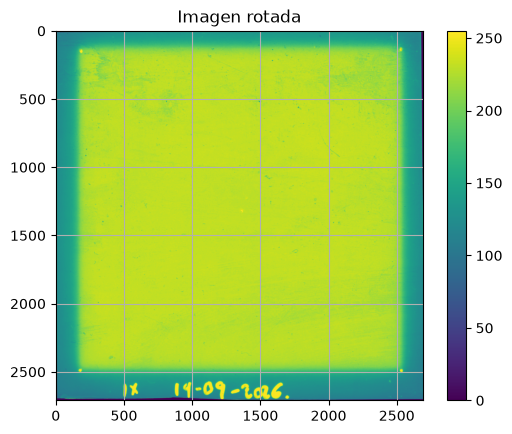

In [38]:
placa_rotada_gray = cv2.warpAffine(placa_analizada_gray, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_analizada_gray)[1], np.shape(placa_analizada_gray)[0]))

plt.imshow(placa_rotada_gray)
plt.title('Imagen rotada')
plt.colorbar()
plt.grid()
plt.show()

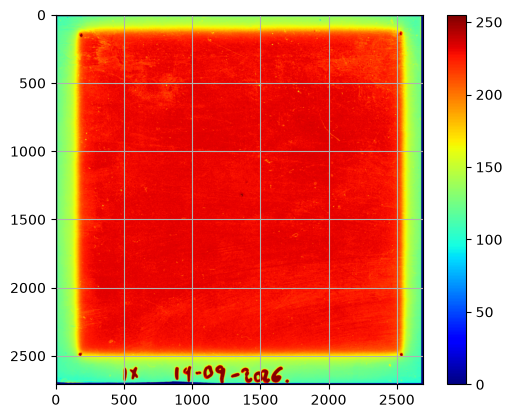

In [39]:
grosor_marco = 20

rectangulo_borde_gray = cv2.rectangle(placa_rotada_gray, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)

plt.imshow(rectangulo_borde_gray, cmap = 'jet')
plt.colorbar()
plt.grid()
plt.show()

Valor de centro blue: 98


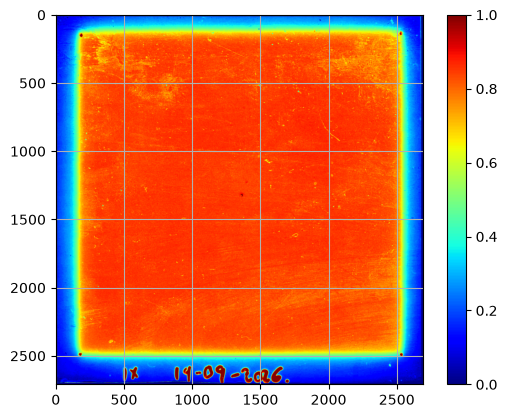

In [40]:
zona_ignorada = grosor_marco + 1

valor_pelicula_gray = int(rectangulo_borde_gray[
    np.shape(rectangulo_borde_gray)[0] - zona_ignorada
][
    np.shape(rectangulo_borde_gray)[1] - zona_ignorada
])
print(f"Valor de centro blue: {valor_pelicula_gray}")

placa_recorte_borde_gray = normalize_image(
    np.where(
        rectangulo_borde_gray <= valor_pelicula_gray,
        valor_pelicula_gray, rectangulo_borde_gray
    )
)

plt.imshow(placa_recorte_borde_gray, cmap = 'jet')
plt.colorbar()
plt.grid()
plt.show()

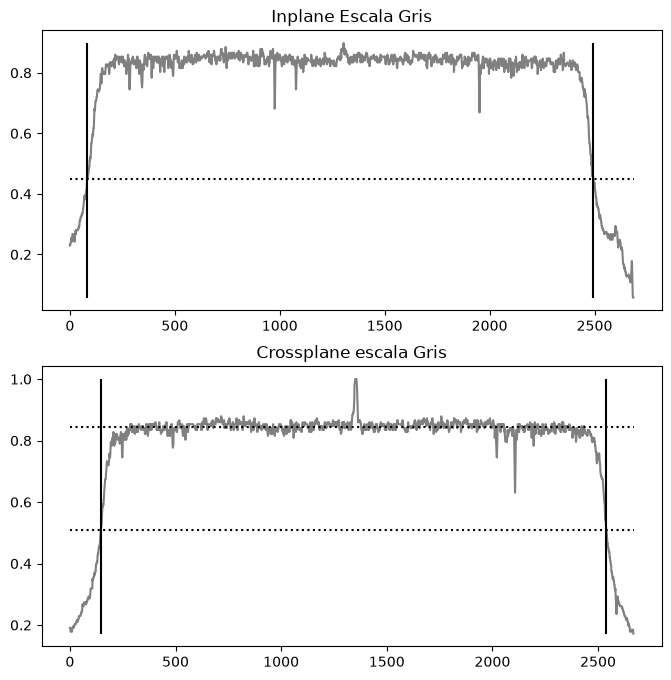

In [41]:
gray_inplane_raw = np.rot90(placa_recorte_borde_gray)[
    np.shape(placa_recorte_borde_gray)[1] - centro_rotacion[0]
]

gray_inplane = gray_inplane_raw[
    1 + int(np.max(np.where(gray_inplane_raw[
        :np.shape(gray_inplane_raw)[0]//2 - extremo_meseta] == 0)[0]))
        :
        int(np.min(np.where(gray_inplane_raw[
            np.shape(gray_inplane_raw)[0]//2 + extremo_meseta:] == 0)[0])) + np.shape(
                gray_inplane_raw)[0]//2 + extremo_meseta - 1
]

media_inplane_gray = (np.mean(
    gray_inplane[
        np.shape(gray_inplane)[0]//2 - extremo_meseta
        :
        np.shape(gray_inplane)[0]//2 - excepcion_centro
        ]) + np.mean(gray_inplane[
            np.shape(gray_inplane)[0]//2 + excepcion_centro
            :
            np.shape(gray_inplane)[0]//2 + extremo_meseta
            ])
) * 0.5

HM_gray = 0.5 * (media_inplane_gray + np.min(gray_inplane))

corte_1i_gray = int(np.abs(
    gray_inplane[
        :np.shape(gray_inplane)[0]//2 - excepcion_centro
    ] - HM_gray
).argmin())

corte_2i_gray = int(np.abs(
    gray_inplane[
        np.shape(gray_inplane)[0]//2 + excepcion_centro:
    ] - HM_gray
).argmin()) + excepcion_centro + np.shape(gray_inplane)[0]//2







gray_crossplane_raw = placa_recorte_borde_gray[
    centro_rotacion[1]
]

gray_crossplane = gray_crossplane_raw[
    1 + int(np.max(np.where(gray_crossplane_raw[
        :np.shape(gray_crossplane_raw)[0]//2 - extremo_meseta] == 0)[0]))
        :
        int(np.min(np.where(gray_crossplane_raw[
            np.shape(gray_crossplane_raw)[0]//2 + extremo_meseta:] == 0)[0])) + np.shape(
                gray_crossplane_raw)[0]//2 + extremo_meseta - 1
]

media_crossplane_gray = (np.mean(
    gray_crossplane[
        np.shape(gray_crossplane)[0]//2 - extremo_meseta
        :
        np.shape(gray_crossplane)[0]//2 - excepcion_centro
        ]) + np.mean(gray_crossplane[
            np.shape(gray_crossplane)[0]//2 + excepcion_centro
            :
            np.shape(gray_crossplane)[0]//2 + extremo_meseta
            ])
) * 0.5

HM_crossplane_gray = 0.5 * (media_crossplane_gray + np.min(gray_crossplane))

corte_1c_gray = int(np.abs(
    gray_crossplane[
        :np.shape(gray_crossplane)[0]//2 - excepcion_centro
    ] - HM_crossplane_gray
).argmin())

corte_2c_gray = int(np.abs(
    gray_crossplane[
        np.shape(gray_crossplane)[0]//2 + excepcion_centro:
    ] - HM_crossplane_gray
).argmin()) + excepcion_centro + np.shape(gray_crossplane)[0]//2

plt.figure(figsize = (8, 8))

plt.subplot(2, 1, 1)
plt.plot(gray_inplane, color = 'gray')
plt.title('Inplane Escala Gris')

plt.hlines(HM_gray, 0, np.shape(gray_inplane)[0], colors = 'black', linestyles = ':')

plt.vlines(corte_1i_gray, np.min(gray_inplane),
           np.max(gray_inplane), colors = 'black', linestyles = "-")
plt.vlines(corte_2i_gray, np.min(gray_inplane),
           np.max(gray_inplane), colors = 'black', linestyles = "-")


plt.subplot(2, 1, 2)
plt.plot(gray_crossplane, color = 'gray')
plt.title('Crossplane escala Gris')

plt.hlines(media_crossplane_gray, 0,
           np.shape(gray_crossplane)[0], colors = 'black', linestyles = ':')
plt.hlines(HM_crossplane_gray, 0,
           np.shape(gray_crossplane)[0], colors = 'black', linestyles = ':')

plt.vlines(corte_1c_gray, np.min(gray_crossplane),
           np.max(gray_crossplane), colors = 'black', linestyles = "-")
plt.vlines(corte_2c_gray, np.min(gray_crossplane),
           np.max(gray_crossplane), colors = 'black', linestyles = "-")

plt.show()

In [42]:
DS

2495

In [43]:
corte_2i_gray

2494

In [44]:
desfase_grayL = LS - corte_1c_gray
desfase_grayR = RS - corte_2c_gray
desfase_grayU = US - corte_1i_gray
desfase_grayD = DS - corte_2i_gray

print('Escala grises')
print(f"Desfase izquierdo: {np.round(desfase_grayL * tamano_pixel, 3)} mm")
print(f"Desfase derecho: {np.round(desfase_grayR * tamano_pixel, 3)} mm")
print(f"Desfase arriba: {np.round(desfase_grayU * tamano_pixel, 3)} mm")
print(f"Desfase abajo: {np.round(desfase_grayD * tamano_pixel, 3)} mm")

Escala grises
Desfase izquierdo: 1.609 mm
Desfase derecho: -0.212 mm
Desfase arriba: 2.625 mm
Desfase abajo: 0.042 mm


## Cuadratura del campo luminoso

Aqui trataremos de reportar resultados de un analisis para cuantificar de forma simple que tan cuadrado es el campo luminoso trazado por los 4 puntos marcados, realmente aqui no importa tanto si se parte de la imagen rotada o no , solamente que tan cuadrado es, particularmente:

- Que tan largo es cada lado.
- Que inclinacion tiene cada lado respecto a su eje correspondiente (Horizontal o vertical).

In [45]:
l_left = punto_DL[1] - punto_UL[1] 
l_right = punto_DR[1] - punto_UR[1]
l_up = punto_UR[0] - punto_UL[0]
l_down = punto_DR[0] - punto_DL[0]

tetha_left =  np.degrees(np.arctan((punto_UL[0] - punto_DL[0])/(punto_UL[1] - punto_DL[1])))
tetha_right =  np.degrees(np.arctan((punto_UR[0] - punto_DR[0])/(punto_UR[1] - punto_DR[1])))
tetha_up =  np.degrees(np.arctan((punto_UL[1] - punto_UR[1])/(punto_UR[0] - punto_UL[0])))
tetha_down =  np.degrees(np.arctan((punto_DL[1] - punto_DR[1])/(punto_DR[0] - punto_DL[0])))


print(f"Angulo izq: {tetha_left}")
print(f"Angulo der: {tetha_right}")
print(f"Angulo arr: {np.round(tetha_up, 3)}")
print(f"Angulo aba: {np.round(tetha_down, 3)}")

print(f"Longitud lado izquierdo: {np.round(l_left * tamano_pixel, 3)} mm")
print(f"Longitud lado derecho: {np.round(l_right * tamano_pixel, 3)} mm")
print(f"Longitud lado superior: {np.round(l_up * tamano_pixel, 3)} mm")
print(f"Longitud lado inferior: {np.round(l_down * tamano_pixel, 3)} mm")

Angulo izq: -0.2201791107041306
Angulo der: 0.02428816281521695
Angulo arr: 0.317
Angulo aba: -0.097
Longitud lado izquierdo: 99.145 mm
Longitud lado derecho: 99.864 mm
Longitud lado superior: 99.314 mm
Longitud lado inferior: 99.737 mm


Pero para reportar el angulo debemos considerar el angulo rotado? No si este es buena referencia, pero no podemos simplemente operar con el porque, entonces en base a que estamos midiendo esos angulos que reportamos. Deberiamos es enderezar uno de los lados y apartir de ese medir los demas., Lo cual deberia ser equivalente a enderezar una de las diagonales y medir los demas angulos respecto a esta, cual elegimos? Pues la de mayor angulo, para que la rotacion tenga mayor impacto y esta va a ser nuestra referencia.

### Para revisar con Claude lo siguiente:

- Es mejor y posible hacer todo esto con una imagen em formaoto .TIF?
- Si se aplica la descomposicion por colores con cv2.split() en b, g y r? En ese orden?
- El zoom esta muy profundo en la app, prefeririria que se viera el perfil completo.
- He visto por ahi que dependiendo de la dosis se le debe crear mas a una capa de color que a otra, entre la roja y la verde, Adriana me dice que normalmente son menos de 10 Grey, como 6 Gy, igual lo que quiero es simplemente mostrar los 3 y toda la inforamcion disponible, incluso la media de los barridos, pero solo para confirmar Claude que sabe de esto y como se refleja esto en cada perfil para saber si estoy obteniendo algo parecido a lo que deberia dar.
- Cual es el signo correcto del angulo que se debe poner y por que?

Nuevas:
- Medir tambien el ancho de la penumbra, se que no es posible si la placa no tiene el tamano suficiente pero dejarlo implementado y reportar el ancho, se puede igual establecer un aviso que junto con el perfil completo informan si los perfiles se encuentran recortados y si ese ancho medido esta incompleto.
- Garantizamos entonces los perfiles crossplane e inplane completos, su FWHM y todas las medidas necesarias para incluirlo con las zonas de interes etc, la forma, tamano y cuadratura de los campos luminosos, el desfase por lado del campo de radiacion frente al campo luminoso y las mediciones de la penumbra.

En braqui mostrar con un zoom mas alejado o casi completo los perfiles por color.